# Task 1: Data Immersion & Wrangling
### ApexPlanet Data Analytics Internship

## Objective

The objective of this task is to familiarize myself with the provided sales dataset and perform the essential first stages of data analysis, including data understanding, quality assessment, cleaning, transformation, and preparation of an analysis-ready dataset.

## Task Workflow

1. Data Access and Familiarization
2. Data Dictionary Creation
3. Data Quality Assessment
4. Missing Value Analysis
5. Duplicate Detection
6. Inconsistent Data Identification
7. Outlier Detection
8. Data Cleaning
9. Data Transformation and Feature Engineering
10. Data Validation
11. Exporting the Final Cleaned Dataset

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

print("Libraries imported successfully.")

Libraries imported successfully.


## 1. Data Access and Familiarization

The first step is to load the provided dataset and understand its structure, variables, data types, size, and general characteristics before performing any cleaning or transformation.

In [3]:
# Identify the project root directory

current_dir = Path.cwd()

if (current_dir / "data").exists():
    project_root = current_dir
elif (current_dir.parent / "data").exists():
    project_root = current_dir.parent
else:
    raise FileNotFoundError("Project data directory could not be located.")

print("Project Root:", project_root)

Project Root: /Users/nabeelahmed/Desktop/intern_task1


In [4]:
file_path = project_root / "data" / "raw" / "ApexPlanet_DataAnalytics_Dataset.xlsx"

print("Dataset Path:", file_path)
print("File Exists:", file_path.exists())

Dataset Path: /Users/nabeelahmed/Desktop/intern_task1/data/raw/ApexPlanet_DataAnalytics_Dataset.xlsx
File Exists: True


In [5]:
df = pd.read_excel(
    file_path,
    sheet_name="Sales_Dataset"
)

print("Dataset loaded successfully.")

Dataset loaded successfully.


### Dataset Preview

The first few records are displayed to understand the structure and type of information available in the dataset.

In [6]:
df.head()

,Order_ID,Order_Date,Customer_ID,Customer_Name,Age,Gender,City,Product,Category,Quantity,Unit_Price,Total_Sales
0,ORD100002,2025-02-25,CUST5529,Customer_227,30.0,Female,Bengaluru,Rice,Grocery,7,2829.77,19808.39
1,ORD100003,2025-10-14,CUST3127,Customer_182,63.0,Male,Bengaluru,Book,Education,5,27906.16,139530.80
2,ORD100004,2025-05-13,CUST8887,Customer_487,62.0,Female,Bengaluru,Book,Education,8,37491.06,299928.48
3,ORD100005,2025-12-02,CUST2515,Customer_470,65.0,Female,Kolkata,Mobile,Electronics,9,28541.36,256872.24
4,ORD100006,2025-11-20,CUST4796,Customer_380,44.0,Male,Bengaluru,Rice,Grocery,10,14036.59,140365.90


In [7]:
print(f"Number of Rows    : {df.shape[0]}")
print(f"Number of Columns : {df.shape[1]}")

Number of Rows    : 1000
Number of Columns : 12


In [8]:
print("Columns in the Dataset:\n")

for i, column in enumerate(df.columns, start=1):
    print(f"{i}. {column}")

Columns in the Dataset:

1. Order_ID
2. Order_Date
3. Customer_ID
4. Customer_Name
5. Age
6. Gender
7. City
8. Product
9. Category
10. Quantity
11. Unit_Price
12. Total_Sales


### Dataset Structure

The dataset information is examined to identify each column's data type, number of non-null records, and memory usage.

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Order_ID       1000 non-null   str    
 1   Order_Date     1000 non-null   str    
 2   Customer_ID    1000 non-null   str    
 3   Customer_Name  1000 non-null   str    
 4   Age            980 non-null    float64
 5   Gender         1000 non-null   str    
 6   City           987 non-null    str    
 7   Product        1000 non-null   str    
 8   Category       1000 non-null   str    
 9   Quantity       1000 non-null   int64  
 10  Unit_Price     1000 non-null   float64
 11  Total_Sales    1000 non-null   float64
dtypes: float64(3), int64(1), str(8)
memory usage: 93.9 KB


### Statistical Summary

Descriptive statistics are generated for numerical variables to understand their distribution, range, central tendency, and potential unusual values.

In [10]:
df.describe()

,Age,Quantity,Unit_Price,Total_Sales
count,980.000000,1000.000000,1000.000000,1000.000000
mean,41.360204,5.435000,25486.783410,139399.439650
std,13.822597,2.838632,14179.402361,114100.051546
min,18.000000,1.000000,145.780000,437.340000
25%,30.000000,3.000000,13895.722500,47066.632500
50%,41.000000,5.000000,25398.740000,108594.025000
75%,54.000000,8.000000,37512.382500,203722.882500
max,65.000000,10.000000,49997.530000,493677.500000


In [11]:
df.describe(include="object")

/var/folders/f6/v72fzl7j7ds5jc7kbxkzkz300000gn/T/ipykernel_88289/702825166.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object")


,Order_ID,Order_Date,Customer_ID,Customer_Name,Gender,City,Product,Category
count,1000,1000,1000,1000,1000,987,1000,1000
unique,992,342,947,425,2,8,6,5
top,ORD100050,2025-04-16,CUST2515,Customer_359,Male,Patna,Mobile,Electronics
freq,9,10,3,8,511,135,184,354


## 2. Data Dictionary

A data dictionary is created to document each variable in the dataset, including its meaning, current data type, expected analytical type, example value, and potential business relevance.

This provides a clear understanding of the dataset before performing data cleaning and transformation.

In [12]:
data_dictionary = pd.DataFrame({
    "Column_Name": [
        "Order_ID",
        "Order_Date",
        "Customer_ID",
        "Customer_Name",
        "Age",
        "Gender",
        "City",
        "Product",
        "Category",
        "Quantity",
        "Unit_Price",
        "Total_Sales"
    ],

    "Description": [
        "Unique identifier assigned to each sales order.",
        "Date on which the order was placed.",
        "Unique identifier assigned to a customer.",
        "Name or label representing the customer.",
        "Age of the customer.",
        "Gender of the customer.",
        "City associated with the customer or order.",
        "Product purchased in the transaction.",
        "Category to which the purchased product belongs.",
        "Number of units purchased in the order.",
        "Price of one unit of the product.",
        "Total monetary value of the sales transaction."
    ],

    "Current_Data_Type": [
        str(df["Order_ID"].dtype),
        str(df["Order_Date"].dtype),
        str(df["Customer_ID"].dtype),
        str(df["Customer_Name"].dtype),
        str(df["Age"].dtype),
        str(df["Gender"].dtype),
        str(df["City"].dtype),
        str(df["Product"].dtype),
        str(df["Category"].dtype),
        str(df["Quantity"].dtype),
        str(df["Unit_Price"].dtype),
        str(df["Total_Sales"].dtype)
    ],

    "Expected_Type": [
        "String",
        "Datetime",
        "String",
        "String",
        "Integer",
        "Categorical",
        "Categorical",
        "Categorical",
        "Categorical",
        "Integer",
        "Float",
        "Float"
    ],

    "Business_Relevance": [
        "Helps uniquely identify and track individual orders.",
        "Enables daily, monthly, seasonal, and time-based sales analysis.",
        "Helps track customer purchasing behaviour.",
        "Provides a readable reference for customer-related analysis.",
        "Supports customer demographic and age-group analysis.",
        "Supports demographic segmentation and comparison.",
        "Enables location-wise and regional sales analysis.",
        "Helps measure product-level demand and performance.",
        "Enables comparison of sales across different product categories.",
        "Measures the volume of items sold.",
        "Used for pricing and revenue-related analysis.",
        "Key metric for measuring sales revenue and transaction value."
    ]
})

data_dictionary

,Column_Name,Description,Current_Data_Type,Expected_Type,Business_Relevance
0,Order_ID,Unique identifier assigned to each sales order.,str,String,Helps uniquely identify and track individual o...
1,Order_Date,Date on which the order was placed.,str,Datetime,"Enables daily, monthly, seasonal, and time-bas..."
2,Customer_ID,Unique identifier assigned to a customer.,str,String,Helps track customer purchasing behaviour.
3,Customer_Name,Name or label representing the customer.,str,String,Provides a readable reference for customer-rel...
4,Age,Age of the customer.,float64,Integer,Supports customer demographic and age-group an...
5,Gender,Gender of the customer.,str,Categorical,Supports demographic segmentation and comparison.
6,City,City associated with the customer or order.,str,Categorical,Enables location-wise and regional sales analy...
7,Product,Product purchased in the transaction.,str,Categorical,Helps measure product-level demand and perform...
8,Category,Category to which the purchased product belongs.,str,Categorical,Enables comparison of sales across different p...
9,Quantity,Number of units purchased in the order.,int64,Integer,Measures the volume of items sold.


In [13]:
data_dictionary["Example_Value"] = [
    df[column].dropna().iloc[0]
    if not df[column].dropna().empty
    else "N/A"
    for column in data_dictionary["Column_Name"]
]

data_dictionary

,Column_Name,Description,Current_Data_Type,Expected_Type,Business_Relevance,Example_Value
0,Order_ID,Unique identifier assigned to each sales order.,str,String,Helps uniquely identify and track individual o...,ORD100002
1,Order_Date,Date on which the order was placed.,str,Datetime,"Enables daily, monthly, seasonal, and time-bas...",2025-02-25
2,Customer_ID,Unique identifier assigned to a customer.,str,String,Helps track customer purchasing behaviour.,CUST5529
3,Customer_Name,Name or label representing the customer.,str,String,Provides a readable reference for customer-rel...,Customer_227
4,Age,Age of the customer.,float64,Integer,Supports customer demographic and age-group an...,30.0
5,Gender,Gender of the customer.,str,Categorical,Supports demographic segmentation and comparison.,Female
6,City,City associated with the customer or order.,str,Categorical,Enables location-wise and regional sales analy...,Bengaluru
7,Product,Product purchased in the transaction.,str,Categorical,Helps measure product-level demand and perform...,Rice
8,Category,Category to which the purchased product belongs.,str,Categorical,Enables comparison of sales across different p...,Grocery
9,Quantity,Number of units purchased in the order.,int64,Integer,Measures the volume of items sold.,7


In [14]:
dictionary_path = (
    project_root
    / "data_dictionary"
    / "data_dictionary.xlsx"
)

data_dictionary.to_excel(
    dictionary_path,
    index=False
)

print("Data dictionary saved successfully.")
print("Saved at:", dictionary_path)

Data dictionary saved successfully.
Saved at: /Users/nabeelahmed/Desktop/intern_task1/data_dictionary/data_dictionary.xlsx


### Initial Dataset Observations

- The dataset contains **1,000 sales records and 12 variables**.
- The variables contain customer, product, transaction, location, pricing, and sales information.
- `Age` contains missing values and currently has a floating-point data type.
- `City` also contains missing values.
- `Order_Date` is currently represented as a string and should be converted to a datetime format during data cleaning.
- `Order_ID` contains fewer unique values than total records, indicating that duplicate or inconsistent order identifiers should be investigated.
- Numerical variables such as `Age`, `Quantity`, `Unit_Price`, and `Total_Sales` will be evaluated further for unusual or potentially invalid values.
- Categorical variables such as `Gender`, `City`, `Product`, and `Category` will be checked for inconsistent spellings, formatting, and unexpected categories.

## 3. Data Quality Assessment

Before cleaning the dataset, a systematic data quality assessment is performed to identify missing values, duplicate records, inconsistent identifiers, incorrect data types, invalid values, formatting inconsistencies, and other potential data quality issues.

The identified issues will be investigated before deciding how they should be handled.

In [15]:
missing_values = pd.DataFrame({
    "Missing_Count": df.isnull().sum(),
    "Missing_Percentage": (df.isnull().sum() / len(df) * 100).round(2)
})

missing_values = missing_values[
    missing_values["Missing_Count"] > 0
]

missing_values

,Missing_Count,Missing_Percentage
Age,20,2.0
City,13,1.3


In [16]:
print("Total missing values in dataset:", df.isnull().sum().sum())

Total missing values in dataset: 33


### Exact Duplicate Records

Exact duplicate rows are checked separately from duplicate identifiers. Two different transactions may legitimately share some values, while a completely duplicated row may indicate repeated data.

In [17]:
exact_duplicates = df.duplicated().sum()

print("Number of exact duplicate rows:", exact_duplicates)

Number of exact duplicate rows: 0


In [18]:
df[df.duplicated(keep=False)]

,Order_ID,Order_Date,Customer_ID,Customer_Name,Age,Gender,City,Product,Category,Quantity,Unit_Price,Total_Sales


In [19]:
print("Total records:", len(df))
print("Unique Order IDs:", df["Order_ID"].nunique())
print("Unique Customer IDs:", df["Customer_ID"].nunique())

Total records: 1000
Unique Order IDs: 992
Unique Customer IDs: 947


In [20]:
order_id_counts = df["Order_ID"].value_counts()

duplicate_order_ids = order_id_counts[
    order_id_counts > 1
]

duplicate_order_ids

Order_ID
ORD100050    9
Name: count, dtype: int64

In [21]:
df[
    df["Order_ID"].isin(duplicate_order_ids.index)
].sort_values("Order_ID")

,Order_ID,Order_Date,Customer_ID,Customer_Name,Age,Gender,City,Product,Category,Quantity,Unit_Price,Total_Sales
48,ORD100050,2025-10-03,CUST5523,Customer_432,NaN,Male,Pune,Chair,Furniture,9,30834.87,277513.83
118,ORD100050,2025-01-22,CUST3194,Customer_114,34.0,Male,Kolkata,Book,Education,2,25795.55,51591.10
238,ORD100050,2025-03-01,CUST8467,Customer_104,23.0,Male,Bengaluru,Book,Education,3,2860.83,8582.49
358,ORD100050,2025-02-11,CUST6467,Customer_181,24.0,Female,Pune,Rice,Grocery,7,45480.39,318362.73
478,ORD100050,2025-11-22,CUST8225,Customer_468,64.0,Male,Bengaluru,Rice,Grocery,8,38957.59,311660.72
598,ORD100050,2025-02-21,CUST8859,Customer_53,NaN,Male,NaN,Laptop,Electronics,7,20144.84,141013.88
718,ORD100050,2025-11-06,CUST7824,Customer_190,31.0,Female,Mumbai,Rice,Grocery,4,42642.59,170570.36
838,ORD100050,2025-08-03,CUST5585,Customer_289,35.0,Male,Kolkata,Chair,Furniture,9,28747.47,258727.23
958,ORD100050,2025-02-09,CUST7188,Customer_89,62.0,Male,Bengaluru,Mobile,Electronics,1,34619.77,34619.77


In [22]:
data_types = pd.DataFrame({
    "Column": df.columns,
    "Current_Data_Type": df.dtypes.astype(str).values
})

data_types

,Column,Current_Data_Type
0,Order_ID,str
1,Order_Date,str
2,Customer_ID,str
3,Customer_Name,str
4,Age,float64
5,Gender,str
6,City,str
7,Product,str
8,Category,str
9,Quantity,int64


In [23]:
categorical_columns = [
    "Gender",
    "City",
    "Product",
    "Category"
]

for column in categorical_columns:
    print(f"\n--- {column} ---")
    print(df[column].value_counts(dropna=False))


--- Gender ---
Gender
Male      511
Female    489
Name: count, dtype: int64

--- City ---
City
Patna        135
Kolkata      133
Mumbai       131
Hyderabad    125
Delhi        125
Bengaluru    122
Gaya         117
Pune          99
NaN           13
Name: count, dtype: int64

--- Product ---
Product
Mobile    184
Book      178
Laptop    170
Chair     159
Shoes     156
Rice      153
Name: count, dtype: int64

--- Category ---
Category
Electronics    354
Education      178
Furniture      159
Fashion        156
Grocery        153
Name: count, dtype: int64


In [24]:
numeric_columns = [
    "Age",
    "Quantity",
    "Unit_Price",
    "Total_Sales"
]

df[numeric_columns].agg(["min", "max", "mean", "median"])

,Age,Quantity,Unit_Price,Total_Sales
min,18.000000,1.000,145.78000,437.34000
max,65.000000,10.000,49997.53000,493677.50000
mean,41.360204,5.435,25486.78341,139399.43965
median,41.000000,5.000,25398.74000,108594.02500


In [25]:
print("Age below 0:", (df["Age"] < 0).sum())
print("Age above 100:", (df["Age"] > 100).sum())

print("Quantity <= 0:", (df["Quantity"] <= 0).sum())

print("Unit Price <= 0:", (df["Unit_Price"] <= 0).sum())

print("Total Sales <= 0:", (df["Total_Sales"] <= 0).sum())

Age below 0: 0
Age above 100: 0
Quantity <= 0: 0
Unit Price <= 0: 0
Total Sales <= 0: 0


In [26]:
df["Calculated_Total"] = (
    df["Quantity"] * df["Unit_Price"]
).round(2)

sales_mismatch = df[
    ~np.isclose(
        df["Total_Sales"],
        df["Calculated_Total"],
        rtol=1e-05,
        atol=0.01
    )
]

print("Rows with Total_Sales mismatch:", len(sales_mismatch))

sales_mismatch.head()

Rows with Total_Sales mismatch: 0


,Order_ID,Order_Date,Customer_ID,Customer_Name,Age,Gender,City,Product,Category,Quantity,Unit_Price,Total_Sales,Calculated_Total


In [27]:
parsed_dates = pd.to_datetime(
    df["Order_Date"],
    errors="coerce"
)

invalid_dates = parsed_dates.isna().sum()

print("Invalid/unparseable dates:", invalid_dates)
print("Earliest Order Date:", parsed_dates.min())
print("Latest Order Date:", parsed_dates.max())

Invalid/unparseable dates: 0
Earliest Order Date: 2025-01-01 00:00:00
Latest Order Date: 2026-01-01 00:00:00


In [28]:
parsed_dates.dt.year.value_counts().sort_index()

Order_Date
2025    995
2026      5
Name: count, dtype: int64

In [30]:
text_columns = df.select_dtypes(include=["str", "object"]).columns

for column in text_columns:
    if df[column].dropna().map(
        lambda x: x != x.strip() if isinstance(x, str) else False
    ).any():
        print(f"Extra spaces detected in: {column}")

In [31]:
quality_summary = pd.DataFrame({
    "Quality_Check": [
        "Total Records",
        "Total Columns",
        "Missing Values",
        "Exact Duplicate Rows",
        "Unique Order IDs",
        "Invalid Dates",
        "Sales Calculation Mismatches"
    ],
    
    "Result": [
        len(df),
        df.shape[1],
        df.isnull().sum().sum(),
        df.duplicated().sum(),
        df["Order_ID"].nunique(),
        invalid_dates,
        len(sales_mismatch)
    ]
})

quality_summary

,Quality_Check,Result
0,Total Records,1000
1,Total Columns,13
2,Missing Values,33
3,Exact Duplicate Rows,0
4,Unique Order IDs,992
5,Invalid Dates,0
6,Sales Calculation Mismatches,0


## 3. Data Quality Assessment

The dataset is assessed for common data quality issues such as missing values, duplicates, invalid values, inconsistent formatting, and incorrect data types before performing any cleaning.

### 3.1 Missing Value Analysis

Missing values are identified to understand which variables contain incomplete information and how much of the dataset is affected.

In [32]:
df.isnull().sum()

Order_ID             0
Order_Date           0
Customer_ID          0
Customer_Name        0
Age                 20
Gender               0
City                13
Product              0
Category             0
Quantity             0
Unit_Price           0
Total_Sales          0
Calculated_Total     0
dtype: int64

In [33]:
missing_summary = pd.DataFrame({
    "Missing_Count": df.isnull().sum(),
    "Missing_Percentage": (
        df.isnull().sum() / len(df) * 100
    ).round(2)
})

missing_summary

,Missing_Count,Missing_Percentage
Order_ID,0,0.0
Order_Date,0,0.0
Customer_ID,0,0.0
Customer_Name,0,0.0
Age,20,2.0
Gender,0,0.0
City,13,1.3
Product,0,0.0
Category,0,0.0
Quantity,0,0.0


In [34]:
missing_summary = missing_summary[
    missing_summary["Missing_Count"] > 0
]

missing_summary

,Missing_Count,Missing_Percentage
Age,20,2.0
City,13,1.3


### Observation

- The `Age` column contains **20 missing values**, representing approximately **2%** of the dataset.
- The `City` column contains **13 missing values**, representing approximately **1.3%** of the dataset.
- No missing values were identified in the remaining columns.
- Since the proportion of missing data is relatively small, appropriate treatment methods will be evaluated during the data cleaning stage instead of removing records immediately.

### 3.2 Duplicate Analysis

Duplicate records are examined to determine whether the dataset contains completely repeated rows or repeated values in important identifier columns such as `Order_ID`.

Repeated customer identifiers are treated separately because a customer may legitimately place multiple orders.

In [35]:
exact_duplicates = df.duplicated().sum()

print("Number of exact duplicate rows:", exact_duplicates)

Number of exact duplicate rows: 0


In [36]:
print("Total Records:", len(df))
print("Unique Order IDs:", df["Order_ID"].nunique())

Total Records: 1000
Unique Order IDs: 992


In [37]:
order_id_counts = df["Order_ID"].value_counts()

duplicate_order_ids = order_id_counts[
    order_id_counts > 1
]

duplicate_order_ids

Order_ID
ORD100050    9
Name: count, dtype: int64

In [38]:
duplicate_order_records = df[
    df["Order_ID"].isin(duplicate_order_ids.index)
]

duplicate_order_records

,Order_ID,Order_Date,Customer_ID,Customer_Name,Age,Gender,City,Product,Category,Quantity,Unit_Price,Total_Sales,Calculated_Total
48,ORD100050,2025-10-03,CUST5523,Customer_432,NaN,Male,Pune,Chair,Furniture,9,30834.87,277513.83,277513.83
118,ORD100050,2025-01-22,CUST3194,Customer_114,34.0,Male,Kolkata,Book,Education,2,25795.55,51591.10,51591.10
238,ORD100050,2025-03-01,CUST8467,Customer_104,23.0,Male,Bengaluru,Book,Education,3,2860.83,8582.49,8582.49
358,ORD100050,2025-02-11,CUST6467,Customer_181,24.0,Female,Pune,Rice,Grocery,7,45480.39,318362.73,318362.73
478,ORD100050,2025-11-22,CUST8225,Customer_468,64.0,Male,Bengaluru,Rice,Grocery,8,38957.59,311660.72,311660.72
598,ORD100050,2025-02-21,CUST8859,Customer_53,NaN,Male,NaN,Laptop,Electronics,7,20144.84,141013.88,141013.88
718,ORD100050,2025-11-06,CUST7824,Customer_190,31.0,Female,Mumbai,Rice,Grocery,4,42642.59,170570.36,170570.36
838,ORD100050,2025-08-03,CUST5585,Customer_289,35.0,Male,Kolkata,Chair,Furniture,9,28747.47,258727.23,258727.23
958,ORD100050,2025-02-09,CUST7188,Customer_89,62.0,Male,Bengaluru,Mobile,Electronics,1,34619.77,34619.77,34619.77


In [39]:
print("Unique Customer IDs:", df["Customer_ID"].nunique())

Unique Customer IDs: 947


### Observation

- No exact duplicate rows were detected in the dataset.
- The number of unique `Order_ID` values is lower than the total number of records, indicating repeated order identifiers.
- The repeated `Order_ID` records require further investigation before making any cleaning decision.
- Repeated `Customer_ID` values are not treated as duplicates because a customer may legitimately place multiple orders.

In [40]:
df.duplicated().sum()

np.int64(0)

In [41]:
df["Order_ID"].nunique()

992

In [42]:
duplicate_order_ids

Order_ID
ORD100050    9
Name: count, dtype: int64

In [43]:
duplicate_order_records

,Order_ID,Order_Date,Customer_ID,Customer_Name,Age,Gender,City,Product,Category,Quantity,Unit_Price,Total_Sales,Calculated_Total
48,ORD100050,2025-10-03,CUST5523,Customer_432,NaN,Male,Pune,Chair,Furniture,9,30834.87,277513.83,277513.83
118,ORD100050,2025-01-22,CUST3194,Customer_114,34.0,Male,Kolkata,Book,Education,2,25795.55,51591.10,51591.10
238,ORD100050,2025-03-01,CUST8467,Customer_104,23.0,Male,Bengaluru,Book,Education,3,2860.83,8582.49,8582.49
358,ORD100050,2025-02-11,CUST6467,Customer_181,24.0,Female,Pune,Rice,Grocery,7,45480.39,318362.73,318362.73
478,ORD100050,2025-11-22,CUST8225,Customer_468,64.0,Male,Bengaluru,Rice,Grocery,8,38957.59,311660.72,311660.72
598,ORD100050,2025-02-21,CUST8859,Customer_53,NaN,Male,NaN,Laptop,Electronics,7,20144.84,141013.88,141013.88
718,ORD100050,2025-11-06,CUST7824,Customer_190,31.0,Female,Mumbai,Rice,Grocery,4,42642.59,170570.36,170570.36
838,ORD100050,2025-08-03,CUST5585,Customer_289,35.0,Male,Kolkata,Chair,Furniture,9,28747.47,258727.23,258727.23
958,ORD100050,2025-02-09,CUST7188,Customer_89,62.0,Male,Bengaluru,Mobile,Electronics,1,34619.77,34619.77,34619.77


### Investigation of Repeated Order IDs

The repeated `Order_ID` records are not exact duplicate transactions. The associated dates, customers, products, quantities, and prices differ across the records.

Therefore, these rows should not be removed. Instead, the repeated identifier is treated as a data integrity issue and investigated further to determine whether the intended Order IDs can be reliably reconstructed.

In [44]:
duplicate_indices = duplicate_order_records.index.tolist()

print("Indexes containing repeated Order_ID:")
print(duplicate_indices)

Indexes containing repeated Order_ID:
[48, 118, 238, 358, 478, 598, 718, 838, 958]


In [45]:
for idx in duplicate_indices:
    start = max(0, idx - 1)
    end = min(len(df) - 1, idx + 1)

    print(f"\nRows around index {idx}:")
    print(
        df.loc[start:end, ["Order_ID", "Order_Date", "Customer_ID"]]
    )


Rows around index 48:
     Order_ID  Order_Date Customer_ID
47  ORD100049  2025-10-25    CUST2705
48  ORD100050  2025-10-03    CUST5523
49  ORD100051  2025-02-27    CUST1557

Rows around index 118:
      Order_ID  Order_Date Customer_ID
117  ORD100119  2025-04-10    CUST7341
118  ORD100050  2025-01-22    CUST3194
119  ORD100121  2025-05-19    CUST9563

Rows around index 238:
      Order_ID  Order_Date Customer_ID
237  ORD100239  2025-02-23    CUST9191
238  ORD100050  2025-03-01    CUST8467
239  ORD100241  2025-02-12    CUST1197

Rows around index 358:
      Order_ID  Order_Date Customer_ID
357  ORD100359  2025-01-26    CUST3763
358  ORD100050  2025-02-11    CUST6467
359  ORD100361  2025-04-26    CUST7309

Rows around index 478:
      Order_ID  Order_Date Customer_ID
477  ORD100479  2025-08-22    CUST9259
478  ORD100050  2025-11-22    CUST8225
479  ORD100481  2025-08-26    CUST4966

Rows around index 598:
      Order_ID  Order_Date Customer_ID
597  ORD100599  2025-03-28    CUST3107
598

In [46]:
# Compare the current Order_ID with the expected sequential Order_ID

id_check = []

for idx in duplicate_indices:
    expected_id = f"ORD{100002 + idx}"

    id_check.append({
        "Row_Index": idx,
        "Current_Order_ID": df.loc[idx, "Order_ID"],
        "Expected_Order_ID": expected_id,
        "Status": "Correct" if df.loc[idx, "Order_ID"] == expected_id else "Incorrect"
    })

id_check_df = pd.DataFrame(id_check)

id_check_df

,Row_Index,Current_Order_ID,Expected_Order_ID,Status
0,48,ORD100050,ORD100050,Correct
1,118,ORD100050,ORD100120,Incorrect
2,238,ORD100050,ORD100240,Incorrect
3,358,ORD100050,ORD100360,Incorrect
4,478,ORD100050,ORD100480,Incorrect
5,598,ORD100050,ORD100600,Incorrect
6,718,ORD100050,ORD100720,Incorrect
7,838,ORD100050,ORD100840,Incorrect
8,958,ORD100050,ORD100960,Incorrect


### Duplicate ID Investigation Conclusion

The repeated `ORD100050` values were investigated using the sequential pattern of the `Order_ID` field.

The record at row index 48 correctly corresponds to `ORD100050`. However, the remaining eight occurrences interrupt the otherwise sequential identifier pattern and represent incorrectly assigned Order IDs.

Therefore, no transaction rows should be deleted. During data cleaning, only the eight incorrect identifiers will be corrected while preserving all transaction records.

### 3.3 Data Type Assessment

The data types of all columns are reviewed to ensure that each variable is stored in a format appropriate for analysis. Incorrect data types can affect calculations, filtering, sorting, grouping, and time-based analysis.

In [47]:
data_types = pd.DataFrame({
    "Column": df.columns,
    "Current_Data_Type": df.dtypes.astype(str).values
})

data_types

,Column,Current_Data_Type
0,Order_ID,str
1,Order_Date,str
2,Customer_ID,str
3,Customer_Name,str
4,Age,float64
5,Gender,str
6,City,str
7,Product,str
8,Category,str
9,Quantity,int64


### Observation

- `Order_Date` is currently stored as a string and should be converted to a datetime data type for time-based analysis.
- `Age` is stored as a floating-point variable because the column contains missing values, although age conceptually represents whole numbers.
- `Quantity` is correctly stored as an integer.
- `Unit_Price` and `Total_Sales` are appropriately stored as numerical floating-point variables.
- Text-based identifiers and categorical variables are currently represented as string values and are suitable for further quality assessment.

### 3.4 Invalid Value and Range Checks

Numerical columns are checked for logically impossible or suspicious values. This helps identify records that may not be missing or duplicated but are still unsuitable for analysis.

In [48]:
print("Age below 0:", (df["Age"] < 0).sum())
print("Age above 100:", (df["Age"] > 100).sum())

print("Quantity <= 0:", (df["Quantity"] <= 0).sum())

print("Unit Price <= 0:", (df["Unit_Price"] <= 0).sum())

print("Total Sales <= 0:", (df["Total_Sales"] <= 0).sum())

Age below 0: 0
Age above 100: 0
Quantity <= 0: 0
Unit Price <= 0: 0
Total Sales <= 0: 0


### 3.5 Categorical Consistency Check

Categorical columns are examined for inconsistent spellings, capitalization, extra spaces, unexpected labels, and missing values that could create incorrect groups during analysis.

In [49]:
categorical_columns = [
    "Gender",
    "City",
    "Product",
    "Category"
]

for column in categorical_columns:
    print(f"\n--- {column} ---")
    print(df[column].value_counts(dropna=False))


--- Gender ---
Gender
Male      511
Female    489
Name: count, dtype: int64

--- City ---
City
Patna        135
Kolkata      133
Mumbai       131
Hyderabad    125
Delhi        125
Bengaluru    122
Gaya         117
Pune          99
NaN           13
Name: count, dtype: int64

--- Product ---
Product
Mobile    184
Book      178
Laptop    170
Chair     159
Shoes     156
Rice      153
Name: count, dtype: int64

--- Category ---
Category
Electronics    354
Education      178
Furniture      159
Fashion        156
Grocery        153
Name: count, dtype: int64


In [50]:
text_columns = ["Gender", "City", "Product", "Category"]

for column in text_columns:
    extra_spaces = df[column].dropna().apply(
        lambda x: x != x.strip()
    ).sum()

    print(f"{column}: {extra_spaces} values with extra spaces")

Gender: 0 values with extra spaces
City: 0 values with extra spaces
Product: 0 values with extra spaces
Category: 0 values with extra spaces


### 3.6 Total Sales Validation

The `Total_Sales` column is validated using the business rule:

`Total_Sales = Quantity × Unit_Price`

This check helps identify calculation errors or inconsistent transaction values.

In [51]:
df["Calculated_Total"] = (
    df["Quantity"] * df["Unit_Price"]
).round(2)

sales_mismatch = df[
    ~np.isclose(
        df["Total_Sales"],
        df["Calculated_Total"],
        atol=0.01
    )
]

print("Rows with Total_Sales mismatch:", len(sales_mismatch))

Rows with Total_Sales mismatch: 0


### Observation

All records satisfy the expected business rule:

`Total_Sales = Quantity × Unit_Price`

No calculation mismatches were identified, indicating that the sales amount values are internally consistent.

### 3.7 Date Quality Check

The `Order_Date` column is examined to verify whether all values can be converted into valid dates. The date range is also reviewed to identify any unusual or unexpected dates.

In [53]:
parsed_dates = pd.to_datetime(
    df["Order_Date"],
    errors="coerce"
)

invalid_dates = parsed_dates.isna().sum()

print("Invalid | Unparseable Dates:", invalid_dates)
print("Earliest Order Date:", parsed_dates.min())
print("Latest Order Date:", parsed_dates.max())

Invalid | Unparseable Dates: 0
Earliest Order Date: 2025-01-01 00:00:00
Latest Order Date: 2026-01-01 00:00:00


In [54]:
parsed_dates.dt.year.value_counts().sort_index()

Order_Date
2025    995
2026      5
Name: count, dtype: int64

In [55]:
df[parsed_dates.dt.year == 2026]

,Order_ID,Order_Date,Customer_ID,Customer_Name,Age,Gender,City,Product,Category,Quantity,Unit_Price,Total_Sales,Calculated_Total
77,ORD100079,2026-01-01,CUST4706,Customer_34,62.0,Female,Delhi,Rice,Grocery,1,35862.34,35862.34,35862.34
163,ORD100165,2026-01-01,CUST8010,Customer_187,41.0,Female,Hyderabad,Rice,Grocery,4,35300.11,141200.44,141200.44
305,ORD100307,2026-01-01,CUST1231,Customer_339,53.0,Male,Patna,Rice,Grocery,4,46771.94,187087.76,187087.76
572,ORD100574,2026-01-01,CUST2343,Customer_39,28.0,Male,Patna,Mobile,Electronics,6,16346.82,98080.92,98080.92
794,ORD100796,2026-01-01,CUST6845,Customer_385,57.0,Female,Mumbai,Shoes,Fashion,9,38573.17,347158.53,347158.53


### Observation

- All `Order_Date` values can be successfully interpreted as valid dates.
- The dataset mainly contains transactions from 2025, with a small number of records extending into early 2026.
- The 2026 records are not considered invalid solely because they belong to a different year.
- `Order_Date` will be converted from string format to a proper datetime data type during the cleaning stage.

### 3.8 Outlier Detection

Numerical variables are examined for unusually high or low values using the Interquartile Range (IQR) method.

Outliers are treated as observations that require investigation rather than being automatically removed, because extreme values may represent legitimate business transactions.

In [56]:
Q1 = df["Total_Sales"].quantile(0.25)
Q3 = df["Total_Sales"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Q1: 47066.6325
Q3: 203722.8825
IQR: 156656.25
Lower Bound: -187917.7425
Upper Bound: 438707.2575


In [58]:
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = data[
        (data[column] < lower_bound) |
        (data[column] > upper_bound)
    ]

    return len(outliers)

/var/folders/f6/v72fzl7j7ds5jc7kbxkzkz300000gn/T/ipykernel_88289/496334184.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


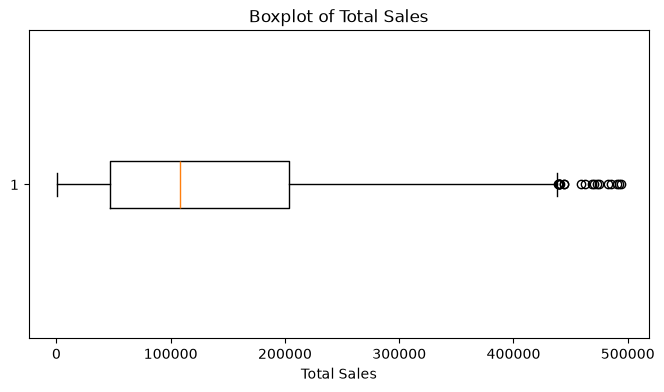

In [59]:
plt.figure(figsize=(8, 4))

plt.boxplot(
    df["Total_Sales"].dropna(),
    vert=False
)

plt.title("Boxplot of Total Sales")
plt.xlabel("Total Sales")

plt.show()

### Observation

- No statistical outliers were identified in `Age`, `Quantity`, or `Unit_Price` using the IQR method.
- `Total_Sales` contains a small number of high-value statistical outliers.
- These high-value transactions are not automatically considered errors because their quantities and unit prices are valid, and the previously performed business-rule check confirmed that `Total_Sales = Quantity × Unit_Price`.
- Therefore, the high-value transactions will be retained unless additional business rules indicate that they are invalid.

### 3.9 Data Quality Summary

After completing the initial data quality assessment, the identified issues are summarized before performing any cleaning or transformation.

This summary helps distinguish actual data quality problems from valid but unusual observations.

In [61]:
# Calculate Total_Sales outliers using IQR method

Q1 = df["Total_Sales"].quantile(0.25)
Q3 = df["Total_Sales"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

total_sales_outliers = df[
    (df["Total_Sales"] < lower_bound) |
    (df["Total_Sales"] > upper_bound)
]

print("Number of Total_Sales outliers:", len(total_sales_outliers))

Number of Total_Sales outliers: 19


In [62]:
quality_summary = pd.DataFrame({
    "Issue": [
        "Missing Age values",
        "Missing City values",
        "Exact duplicate rows",
        "Incorrect repeated Order IDs",
        "Order_Date data type",
        "Invalid numerical values",
        "Total Sales calculation errors",
        "Categorical inconsistencies",
        "Total_Sales statistical outliers"
    ],

    "Finding": [
        20,
        13,
        df.duplicated().sum(),
        8,
        str(df["Order_Date"].dtype),
        0,
        len(sales_mismatch),
        "None detected",
        len(total_sales_outliers)
    ],

    "Planned_Action": [
        "Handle during cleaning",
        "Handle during cleaning",
        "No action required",
        "Correct identifiers",
        "Convert to datetime",
        "No action required",
        "No action required",
        "No action required",
        "Retain after validation"
    ]
})

quality_summary

,Issue,Finding,Planned_Action
0,Missing Age values,20,Handle during cleaning
1,Missing City values,13,Handle during cleaning
2,Exact duplicate rows,0,No action required
3,Incorrect repeated Order IDs,8,Correct identifiers
4,Order_Date data type,str,Convert to datetime
5,Invalid numerical values,0,No action required
6,Total Sales calculation errors,0,No action required
7,Categorical inconsistencies,None detected,No action required
8,Total_Sales statistical outliers,19,Retain after validation


## 4. Data Cleaning & Transformation

Based on the issues identified during the data quality assessment, a separate copy of the dataset is created for cleaning and transformation.

The original loaded dataset is preserved so that all cleaning operations remain traceable and reversible.

In [63]:
df_clean = df.copy()

print("Cleaning copy created successfully.")
print("Shape:", df_clean.shape)

Cleaning copy created successfully.
Shape: (1000, 13)


In [64]:
if "Calculated_Total" in df_clean.columns:
    df_clean.drop(columns=["Calculated_Total"], inplace=True)

print("Number of columns after removing temporary columns:", df_clean.shape[1])

Number of columns after removing temporary columns: 12


### 4.1 Correction of Invalid Order Identifiers

The `Order_ID` sequence is validated against the observed sequential identifier pattern before applying any corrections. This ensures that identifiers are corrected only when the intended value can be reliably determined.

In [65]:
expected_order_ids = [
    f"ORD{100002 + idx}"
    for idx in df_clean.index
]

order_id_mismatch_mask = (
    df_clean["Order_ID"] != expected_order_ids
)

print(
    "Number of Order_ID mismatches:",
    order_id_mismatch_mask.sum()
)

Number of Order_ID mismatches: 8


In [66]:
order_id_issues = df_clean.loc[
    order_id_mismatch_mask,
    ["Order_ID"]
].copy()

order_id_issues["Expected_Order_ID"] = [
    expected_order_ids[idx]
    for idx in order_id_issues.index
]

order_id_issues

,Order_ID,Expected_Order_ID
118,ORD100050,ORD100120
238,ORD100050,ORD100240
358,ORD100050,ORD100360
478,ORD100050,ORD100480
598,ORD100050,ORD100600
718,ORD100050,ORD100720
838,ORD100050,ORD100840
958,ORD100050,ORD100960


In [67]:
for idx in df_clean.index:
    expected_id = f"ORD{100002 + idx}"

    if df_clean.loc[idx, "Order_ID"] != expected_id:
        df_clean.loc[idx, "Order_ID"] = expected_id

print("Order_ID corrections completed.")

Order_ID corrections completed.


In [68]:
print(
    "Unique Order IDs after correction:",
    df_clean["Order_ID"].nunique()
)

print(
    "Duplicate Order IDs after correction:",
    df_clean["Order_ID"].duplicated().sum()
)

Unique Order IDs after correction: 1000
Duplicate Order IDs after correction: 0


### Observation

Eight incorrectly assigned `Order_ID` values were identified using the verified sequential identifier pattern.

The affected identifiers were corrected without deleting any transaction records. After correction, all 1,000 transactions contain unique `Order_ID` values.

In [69]:
print("Before conversion:")
print(df_clean["Order_Date"].dtype)

Before conversion:
str


In [70]:
df_clean["Order_Date"] = pd.to_datetime(
    df_clean["Order_Date"],
    errors="coerce"
)

print("Order_Date converted successfully.")

Order_Date converted successfully.


In [71]:
print("After conversion:")
print(df_clean["Order_Date"].dtype)

print(
    "Missing dates after conversion:",
    df_clean["Order_Date"].isna().sum()
)

After conversion:
datetime64[us]
Missing dates after conversion: 0


In [72]:
print("Earliest Order Date:", df_clean["Order_Date"].min())
print("Latest Order Date:", df_clean["Order_Date"].max())

df_clean[["Order_ID", "Order_Date"]].head()

Earliest Order Date: 2025-01-01 00:00:00
Latest Order Date: 2026-01-01 00:00:00


,Order_ID,Order_Date
0,ORD100002,2025-02-25
1,ORD100003,2025-10-14
2,ORD100004,2025-05-13
3,ORD100005,2025-12-02
4,ORD100006,2025-11-20


### Observation

The `Order_Date` column was converted from string format to a proper datetime data type. No values were lost during conversion, confirming that all existing order dates were valid and suitable for time-based analysis.

### 4.3 Handling Missing Age Values

The `Age` column contains 20 missing values (2% of the dataset). Since removing these rows would result in the loss of otherwise valid transaction data, an appropriate imputation method is evaluated.

Mean, median, and mode values are compared before selecting the replacement strategy.

In [73]:
age_mean = df_clean["Age"].mean()
age_median = df_clean["Age"].median()
age_mode = df_clean["Age"].mode()[0]

print("Mean Age:", round(age_mean, 2))
print("Median Age:", age_median)
print("Mode Age:", age_mode)

Mean Age: 41.36
Median Age: 41.0
Mode Age: 30.0


In [74]:
print(
    "Missing Age values before cleaning:",
    df_clean["Age"].isna().sum()
)

Missing Age values before cleaning: 20


In [75]:
df_clean["Age"] = df_clean["Age"].fillna(age_median)

print("Missing Age values filled with median age.")

Missing Age values filled with median age.


In [76]:
print(
    "Missing Age values after cleaning:",
    df_clean["Age"].isna().sum()
)

Missing Age values after cleaning: 0


In [77]:
df_clean["Age"] = df_clean["Age"].astype(int)

print("Age data type:", df_clean["Age"].dtype)

Age data type: int64


In [78]:
df_clean["Age"].describe()

count    1000.000000
mean       41.353000
std        13.683626
min        18.000000
25%        30.000000
50%        41.000000
75%        53.000000
max        65.000000
Name: Age, dtype: float64

In [79]:
print("Missing Age:", df_clean["Age"].isna().sum())
print("Minimum Age:", df_clean["Age"].min())
print("Maximum Age:", df_clean["Age"].max())

Missing Age: 0
Minimum Age: 18
Maximum Age: 65


### Observation

The `Age` column contained 20 missing values, representing 2% of the dataset. Since the remaining transaction information was valid, these records were retained rather than deleted.

The median age of 41 years was used to impute the missing values. Median imputation provides a representative central value while being less sensitive to extreme observations.

After imputation, the `Age` column contains no missing values and was converted to an integer data type.

### 4.4 Handling Missing City Values

The `City` column contains 13 missing values (1.3% of the dataset). Since the city cannot be reliably inferred from the other available attributes, missing values are handled using an explicit `Unknown` category rather than assigning them to the most frequent city.

In [80]:
print("Missing City values before cleaning:",
      df_clean["City"].isna().sum())

print("\nCity distribution:")
print(df_clean["City"].value_counts(dropna=False))

Missing City values before cleaning: 13

City distribution:
City
Patna        135
Kolkata      133
Mumbai       131
Hyderabad    125
Delhi        125
Bengaluru    122
Gaya         117
Pune          99
NaN           13
Name: count, dtype: int64


In [81]:
df_clean["City"] = df_clean["City"].fillna("Unknown")

print("Missing City values filled with 'Unknown'.")

Missing City values filled with 'Unknown'.


In [82]:
print(
    "Missing City values after cleaning:",
    df_clean["City"].isna().sum()
)

print("\nUpdated City distribution:")
print(df_clean["City"].value_counts())

Missing City values after cleaning: 0

Updated City distribution:
City
Patna        135
Kolkata      133
Mumbai       131
Hyderabad    125
Delhi        125
Bengaluru    122
Gaya         117
Pune          99
Unknown       13
Name: count, dtype: int64


### Observation

The `City` column contained 13 missing values. Since the actual city could not be reliably inferred from the available data, these values were replaced with `Unknown`.

This approach preserves valid transaction records while avoiding assumptions that could distort city-level analysis.

### 4.5 Text Standardization

Text-based categorical fields are standardized to remove accidental leading or trailing spaces while preserving the original information.

In [83]:
text_columns = [
    "Order_ID",
    "Customer_ID",
    "Customer_Name",
    "Gender",
    "City",
    "Product",
    "Category"
]

for column in text_columns:
    df_clean[column] = df_clean[column].str.strip()

print("Text columns standardized successfully.")

Text columns standardized successfully.


## 5. Data Transformation and Feature Engineering

New analytical features are derived from existing variables to make the cleaned dataset more useful for demographic and time-based analysis.

In [84]:
# Extract date-based features

df_clean["Order_Year"] = df_clean["Order_Date"].dt.year
df_clean["Order_Month"] = df_clean["Order_Date"].dt.month
df_clean["Order_Month_Name"] = df_clean["Order_Date"].dt.month_name()

print("Date-based features created.")

Date-based features created.


In [85]:
age_bins = [17, 25, 35, 45, 55, 65]

age_labels = [
    "18-25",
    "26-35",
    "36-45",
    "46-55",
    "56-65"
]

df_clean["Age_Group"] = pd.cut(
    df_clean["Age"],
    bins=age_bins,
    labels=age_labels
)

print("Age_Group feature created.")

Age_Group feature created.


In [86]:
df_clean[
    [
        "Order_Date",
        "Order_Year",
        "Order_Month",
        "Order_Month_Name",
        "Age",
        "Age_Group"
    ]
].head(10)

,Order_Date,Order_Year,Order_Month,Order_Month_Name,Age,Age_Group
0,2025-02-25,2025,2,February,30,26-35
1,2025-10-14,2025,10,October,63,56-65
2,2025-05-13,2025,5,May,62,56-65
3,2025-12-02,2025,12,December,65,56-65
4,2025-11-20,2025,11,November,44,36-45
5,2025-12-31,2025,12,December,40,36-45
6,2025-10-14,2025,10,October,61,56-65
7,2025-12-05,2025,12,December,35,26-35
8,2025-11-21,2025,11,November,41,36-45
9,2025-04-16,2025,4,April,30,26-35


### Feature Engineering Summary

- `Order_Year` was extracted to support yearly sales analysis.
- `Order_Month` was created for chronological monthly analysis.
- `Order_Month_Name` provides a readable month label for reporting and visualization.
- `Age_Group` was derived from customer age to support demographic segmentation.

In [87]:
new_dictionary_rows = pd.DataFrame({
    "Column_Name": [
        "Order_Year",
        "Order_Month",
        "Order_Month_Name",
        "Age_Group"
    ],

    "Description": [
        "Year extracted from the order date.",
        "Numerical month extracted from the order date.",
        "Readable month name extracted from the order date.",
        "Customer age grouped into predefined demographic ranges."
    ],

    "Current_Data_Type": [
        str(df_clean["Order_Year"].dtype),
        str(df_clean["Order_Month"].dtype),
        str(df_clean["Order_Month_Name"].dtype),
        str(df_clean["Age_Group"].dtype)
    ],

    "Expected_Type": [
        "Integer",
        "Integer",
        "Categorical",
        "Categorical"
    ],

    "Business_Relevance": [
        "Supports yearly sales trend analysis.",
        "Supports chronological monthly sales analysis.",
        "Improves readability in monthly reports and visualizations.",
        "Supports customer demographic segmentation."
    ],

    "Example_Value": [
        df_clean["Order_Year"].iloc[0],
        df_clean["Order_Month"].iloc[0],
        df_clean["Order_Month_Name"].iloc[0],
        str(df_clean["Age_Group"].iloc[0])
    ]
})

final_data_dictionary = pd.concat(
    [data_dictionary, new_dictionary_rows],
    ignore_index=True
)

final_data_dictionary

,Column_Name,Description,Current_Data_Type,Expected_Type,Business_Relevance,Example_Value
0,Order_ID,Unique identifier assigned to each sales order.,str,String,Helps uniquely identify and track individual o...,ORD100002
1,Order_Date,Date on which the order was placed.,str,Datetime,"Enables daily, monthly, seasonal, and time-bas...",2025-02-25
2,Customer_ID,Unique identifier assigned to a customer.,str,String,Helps track customer purchasing behaviour.,CUST5529
3,Customer_Name,Name or label representing the customer.,str,String,Provides a readable reference for customer-rel...,Customer_227
4,Age,Age of the customer.,float64,Integer,Supports customer demographic and age-group an...,30.0
5,Gender,Gender of the customer.,str,Categorical,Supports demographic segmentation and comparison.,Female
6,City,City associated with the customer or order.,str,Categorical,Enables location-wise and regional sales analy...,Bengaluru
7,Product,Product purchased in the transaction.,str,Categorical,Helps measure product-level demand and perform...,Rice
8,Category,Category to which the purchased product belongs.,str,Categorical,Enables comparison of sales across different p...,Grocery
9,Quantity,Number of units purchased in the order.,int64,Integer,Measures the volume of items sold.,7


In [88]:
dictionary_path = (
    project_root
    / "data_dictionary"
    / "data_dictionary.xlsx"
)

final_data_dictionary.to_excel(
    dictionary_path,
    index=False
)

print("Updated data dictionary saved successfully.")

Updated data dictionary saved successfully.


## 6. Final Data Validation

The cleaned and transformed dataset is validated to ensure that the identified quality issues have been resolved without unintentionally losing valid transaction records.

In [89]:
print("FINAL DATASET VALIDATION")
print("-" * 40)

print("Rows:", df_clean.shape[0])
print("Columns:", df_clean.shape[1])

print("\nMissing Values:")
print(df_clean.isnull().sum())

print("\nExact Duplicate Rows:",
      df_clean.duplicated().sum())

print("Unique Order IDs:",
      df_clean["Order_ID"].nunique())

print("Duplicate Order IDs:",
      df_clean["Order_ID"].duplicated().sum())

print("Invalid Dates:",
      df_clean["Order_Date"].isna().sum())

print("Age below 18:",
      (df_clean["Age"] < 18).sum())

print("Age above 65:",
      (df_clean["Age"] > 65).sum())

print("Quantity <= 0:",
      (df_clean["Quantity"] <= 0).sum())

print("Unit Price <= 0:",
      (df_clean["Unit_Price"] <= 0).sum())

print("Total Sales <= 0:",
      (df_clean["Total_Sales"] <= 0).sum())

FINAL DATASET VALIDATION
----------------------------------------
Rows: 1000
Columns: 16

Missing Values:
Order_ID            0
Order_Date          0
Customer_ID         0
Customer_Name       0
Age                 0
Gender              0
City                0
Product             0
Category            0
Quantity            0
Unit_Price          0
Total_Sales         0
Order_Year          0
Order_Month         0
Order_Month_Name    0
Age_Group           0
dtype: int64

Exact Duplicate Rows: 0
Unique Order IDs: 1000
Duplicate Order IDs: 0
Invalid Dates: 0
Age below 18: 0
Age above 65: 0
Quantity <= 0: 0
Unit Price <= 0: 0
Total Sales <= 0: 0


In [90]:
final_calculated_sales = (
    df_clean["Quantity"] *
    df_clean["Unit_Price"]
)

final_sales_mismatch = ~np.isclose(
    df_clean["Total_Sales"],
    final_calculated_sales,
    atol=0.01
)

print(
    "Total Sales calculation mismatches:",
    final_sales_mismatch.sum()
)

Total Sales calculation mismatches: 0


In [91]:
print(
    "Missing Age Groups:",
    df_clean["Age_Group"].isna().sum()
)

Missing Age Groups: 0


In [92]:
final_summary = pd.DataFrame({
    "Check": [
        "Total Records",
        "Missing Values",
        "Exact Duplicate Rows",
        "Unique Order IDs",
        "Duplicate Order IDs",
        "Invalid Dates",
        "Sales Calculation Errors"
    ],

    "Final_Result": [
        len(df_clean),
        df_clean.isnull().sum().sum(),
        df_clean.duplicated().sum(),
        df_clean["Order_ID"].nunique(),
        df_clean["Order_ID"].duplicated().sum(),
        df_clean["Order_Date"].isna().sum(),
        final_sales_mismatch.sum()
    ]
})

final_summary

,Check,Final_Result
0,Total Records,1000
1,Missing Values,0
2,Exact Duplicate Rows,0
3,Unique Order IDs,1000
4,Duplicate Order IDs,0
5,Invalid Dates,0
6,Sales Calculation Errors,0


## 7. Final Conclusion

The raw sales dataset was successfully assessed, cleaned, transformed, and validated for further analysis.

### Key Cleaning Actions

- Investigated missing and inconsistent information.
- Imputed 20 missing customer age values using the median age.
- Replaced 13 missing city values with `Unknown`.
- Investigated repeated order identifiers and corrected eight incorrectly assigned `Order_ID` values without removing valid transactions.
- Converted `Order_Date` from string format to datetime.
- Validated numerical ranges and transaction sales calculations.
- Investigated statistical outliers and retained valid high-value transactions.
- Standardized text-based columns.
- Created additional analytical features including year, month, month name, and customer age group.

### Final Outcome

The resulting dataset contains clean, consistent, and analysis-ready sales records while preserving all valid transactions.

In [93]:
cleaned_folder = project_root / "data" / "cleaned"

excel_output = (
    cleaned_folder /
    "cleaned_sales_dataset.xlsx"
)

csv_output = (
    cleaned_folder /
    "cleaned_sales_dataset.csv"
)

df_clean.to_excel(
    excel_output,
    index=False
)

df_clean.to_csv(
    csv_output,
    index=False
)

print("Cleaned datasets exported successfully.")
print("Excel:", excel_output)
print("CSV:", csv_output)

Cleaned datasets exported successfully.
Excel: /Users/nabeelahmed/Desktop/intern_task1/data/cleaned/cleaned_sales_dataset.xlsx
CSV: /Users/nabeelahmed/Desktop/intern_task1/data/cleaned/cleaned_sales_dataset.csv


In [94]:
df_clean.head()

,Order_ID,Order_Date,Customer_ID,Customer_Name,Age,Gender,City,Product,Category,Quantity,Unit_Price,Total_Sales,Order_Year,Order_Month,Order_Month_Name,Age_Group
0,ORD100002,2025-02-25,CUST5529,Customer_227,30,Female,Bengaluru,Rice,Grocery,7,2829.77,19808.39,2025,2,February,26-35
1,ORD100003,2025-10-14,CUST3127,Customer_182,63,Male,Bengaluru,Book,Education,5,27906.16,139530.80,2025,10,October,56-65
2,ORD100004,2025-05-13,CUST8887,Customer_487,62,Female,Bengaluru,Book,Education,8,37491.06,299928.48,2025,5,May,56-65
3,ORD100005,2025-12-02,CUST2515,Customer_470,65,Female,Kolkata,Mobile,Electronics,9,28541.36,256872.24,2025,12,December,56-65
4,ORD100006,2025-11-20,CUST4796,Customer_380,44,Male,Bengaluru,Rice,Grocery,10,14036.59,140365.90,2025,11,November,36-45


In [95]:
df_clean.shape

(1000, 16)

In [96]:
df_clean.isnull().sum()

Order_ID            0
Order_Date          0
Customer_ID         0
Customer_Name       0
Age                 0
Gender              0
City                0
Product             0
Category            0
Quantity            0
Unit_Price          0
Total_Sales         0
Order_Year          0
Order_Month         0
Order_Month_Name    0
Age_Group           0
dtype: int64

In [97]:
df_clean["Order_ID"].nunique()

1000

In [98]:
df_clean.head()

,Order_ID,Order_Date,Customer_ID,Customer_Name,Age,Gender,City,Product,Category,Quantity,Unit_Price,Total_Sales,Order_Year,Order_Month,Order_Month_Name,Age_Group
0,ORD100002,2025-02-25,CUST5529,Customer_227,30,Female,Bengaluru,Rice,Grocery,7,2829.77,19808.39,2025,2,February,26-35
1,ORD100003,2025-10-14,CUST3127,Customer_182,63,Male,Bengaluru,Book,Education,5,27906.16,139530.80,2025,10,October,56-65
2,ORD100004,2025-05-13,CUST8887,Customer_487,62,Female,Bengaluru,Book,Education,8,37491.06,299928.48,2025,5,May,56-65
3,ORD100005,2025-12-02,CUST2515,Customer_470,65,Female,Kolkata,Mobile,Electronics,9,28541.36,256872.24,2025,12,December,56-65
4,ORD100006,2025-11-20,CUST4796,Customer_380,44,Male,Bengaluru,Rice,Grocery,10,14036.59,140365.90,2025,11,November,36-45
